# 06E - LightGBM Classifier (Execution-Ready)

Optimized professional notebook. Run **Run All** to generate and save outputs.

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay
)

df = pd.read_csv("../data/datasets/american_bankruptcy.csv")
df["target"] = df["status_label"].map({"alive": 0, "failed": 1})

display(df.head())
print(df.shape)


,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X10,X11,X12,X13,X14,X15,X16,X17,X18,target
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302,0
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888,0
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514,0
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592,0
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467,0


(78682, 22)


## Data Preparation

In [2]:
drop_cols = ["status_label", "target"]
if "company_name" in df.columns:
    drop_cols.append("company_name")

X = df.drop(columns=drop_cols)
y = df["target"]

num = X.select_dtypes(include="number").columns
cat = X.select_dtypes(exclude="number").columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("enc", OneHotEncoder(handle_unknown="ignore"))
    ]), cat)
])


## Train LightGBM Model

In [3]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 4176, number of negative: 58769
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4611
[LightGBM] [Info] Number of data points in the train set: 62945, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Cross Validation

In [4]:
cv = cross_validate(
    model,
    X_train,
    y_train,
    cv=3,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

display(pd.DataFrame(cv).describe())


[LightGBM] [Info] Number of positive: 2784, number of negative: 39179
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005733 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4611
[LightGBM] [Info] Number of data points in the train set: 41963, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


[LightGBM] [Info] Number of positive: 2784, number of negative: 39179
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005895 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4611
[LightGBM] [Info] Number of data points in the train set: 41963, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


[LightGBM] [Info] Number of positive: 2784, number of negative: 39180
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4611
[LightGBM] [Info] Number of data points in the train set: 41964, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
count,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
mean,0.625157,0.264686,0.771960,0.180840,0.690852,0.286629,0.819806
std,0.023568,0.049370,0.002329,0.005062,0.033421,0.009146,0.009144
min,0.604254,0.232561,0.769946,0.177586,0.664511,0.281112,0.814488
25%,0.612385,0.236262,0.770684,0.177924,0.672055,0.281351,0.814527
50%,0.620516,0.239963,0.771423,0.178262,0.679598,0.281590,0.814566
75%,0.635608,0.280748,0.772967,0.182467,0.704023,0.289388,0.822465
max,0.650700,0.321532,0.774510,0.186672,0.728448,0.297186,0.830364


## Model Evaluation

In [5]:
pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:, 1]

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Value": [
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ]
})

display(metrics)
print(classification_report(y_test, pred))


,Metric,Value
0,Accuracy,0.759103
1,Precision,0.179463
2,Recall,0.736590
3,F1,0.288609
4,ROC-AUC,0.836080


              precision    recall  f1-score   support

           0       0.98      0.76      0.86     14693
           1       0.18      0.74      0.29      1044

    accuracy                           0.76     15737
   macro avg       0.58      0.75      0.57     15737
weighted avg       0.92      0.76      0.82     15737



## Visualizations

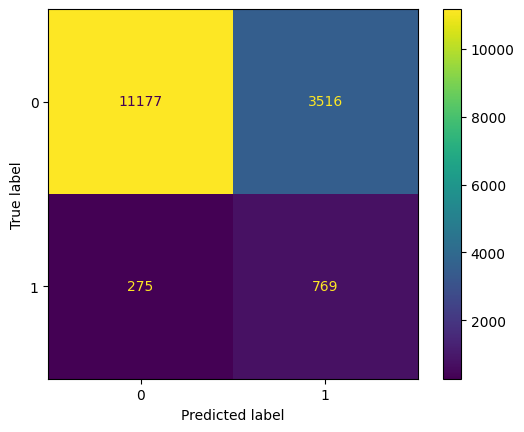

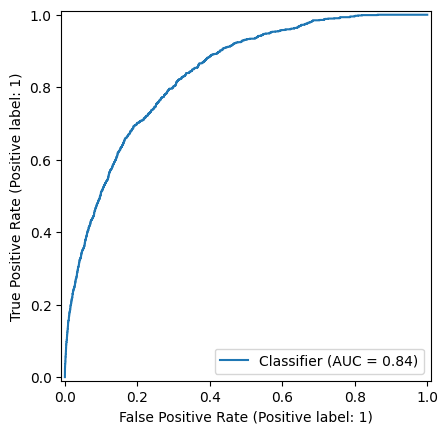

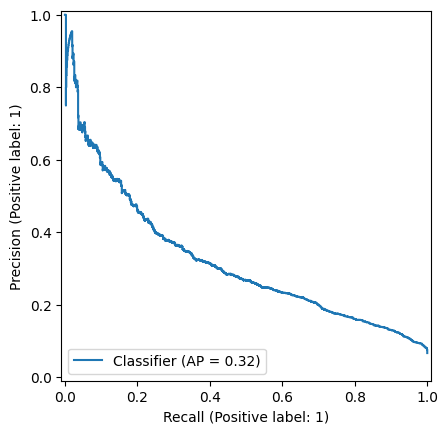

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.show()

RocCurveDisplay.from_predictions(y_test, prob)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, prob)
plt.show()


## Feature Importance

In [7]:
lgbm = model.named_steps["classifier"]

features = list(num)
if len(cat):
    features.extend(
        model.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .named_steps["enc"]
        .get_feature_names_out(cat)
    )

importance = (
    pd.DataFrame({
        "Feature": features,
        "Importance": lgbm.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

display(importance.head(20))


,Feature,Importance
8,X8,257
15,X15,247
3,X3,243
5,X5,231
1,X1,182
17,X17,176
13,X13,174
0,year,169
7,X7,168
2,X2,164


## Save Model

In [8]:
joblib.dump(model, "lightgbm_model.joblib")
print("Saved lightgbm_model.joblib")


Saved lightgbm_model.joblib
